  Domain Code Domain  Area Code         Area  Element Code         Element  \
0          QC  Crops          2  Afghanistan          5312  Area harvested   
1          QC  Crops          2  Afghanistan          5312  Area harvested   
2          QC  Crops          2  Afghanistan          5312  Area harvested   
3          QC  Crops          2  Afghanistan          5312  Area harvested   
4          QC  Crops          2  Afghanistan          5312  Area harvested   

   Item Code   Item  Year Code  Year Unit     Value Flag Flag Description  
0         56  Maize       1961  1961   ha  500000.0  NaN    Official data  
1         56  Maize       1962  1962   ha  500000.0  NaN    Official data  
2         56  Maize       1963  1963   ha  500000.0  NaN    Official data  
3         56  Maize       1964  1964   ha  505000.0  NaN    Official data  
4         56  Maize       1965  1965   ha  500000.0  NaN    Official data  
<class 'pandas.DataFrame'>
RangeIndex: 8919 entries, 0 to 8918
Data columns

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_11857/3751044424.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns



Cluster results:
                                                 text  Cluster
0   QC Crops Afghanistan Area harvested Maize ha  ...        0
1   QC Crops Afghanistan Area harvested Maize ha  ...        0
2   QC Crops Afghanistan Area harvested Maize ha  ...        0
3   QC Crops Afghanistan Area harvested Maize ha  ...        0
4   QC Crops Afghanistan Area harvested Maize ha  ...        0
5   QC Crops Afghanistan Area harvested Maize ha  ...        0
6   QC Crops Afghanistan Area harvested Maize ha  ...        0
7   QC Crops Afghanistan Area harvested Maize ha  ...        0
8   QC Crops Afghanistan Area harvested Maize ha  ...        0
9   QC Crops Afghanistan Area harvested Maize ha  ...        0
10  QC Crops Afghanistan Area harvested Maize ha  ...        0
11  QC Crops Afghanistan Area harvested Maize ha  ...        0
12  QC Crops Afghanistan Area harvested Maize ha  ...        0
13  QC Crops Afghanistan Area harvested Maize ha  ...        0
14  QC Crops Afghanistan Area harvest

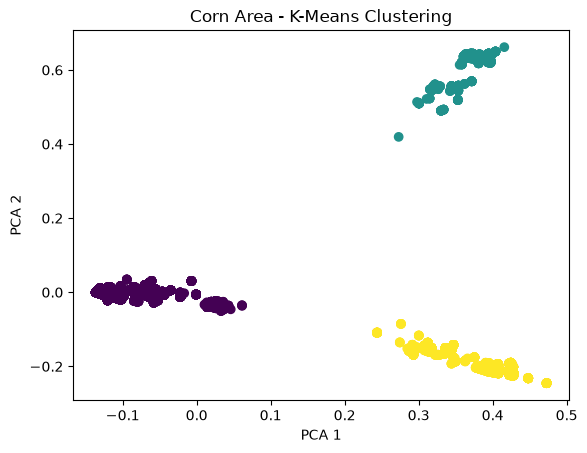

Saved as corn_area_clustered.csv


In [1]:
# K-MEANS + NLP on corn_area.csv

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load data
df = pd.read_csv("corn_area.csv")
print(df.head())
print(df.info())

# 2. Combine text columns
text_cols = df.select_dtypes(include="object").columns

df["text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

# 3. NLP - TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(df["text"])

# 4. K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# 5. Show results
print("\nCluster results:")
print(df[["text", "Cluster"]].head(20))

print("\nCluster counts:")
print(df["Cluster"].value_counts())

# 6. Visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Corn Area - K-Means Clustering")
plt.show()

# 7. Save results
df.to_csv("corn_area_clustered.csv", index=False)
print("Saved as corn_area_clustered.csv")